Building the vector database 
- Preprocess and embed all NACE 2.1 code descriptions using a dedicated language model
- Store the resulting vectors in a Qdrant collection
- Understand what a vector database is and how nearest-neighbour search works

In [ ]:
# .env KLUCZE DOSTĘPU
QDRANT_URL=https://YOURNAMESPACE-qdrant.user.lab.sspcloud.fr/
QDRANT_API_KEY=xxxxxxxxxxxxxxxxxxxx
QDRANT_API_PORT=443
LLMLAB_API_KEY=xxxxxxxxxxxxxxxxxxxx
LLMLAB_URL=https://llm.lab.sspcloud.fr/api

In [3]:
#ZAŁADOWANIE UPRAWNIEŃ
from dotenv import load_dotenv
load_dotenv()

import os
try:
    QDRANT_URL = os.environ["QDRANT_URL"]
    print("QDRANT_URL loaded successfully")
except KeyError:
    raise ValueError("QDRANT_URL is not set — check your .env file")

QDRANT_URL loaded successfully


# **workflow**

0. Create a proper working environment with all needed connections (s3: object storage, qdrant: vector database and llm.lab: LLM provider)
1. Take the NACE2.1 code definitions (code + title, + inclusions + exclusions in plain text)
2. Concatenate these pieces of information for each unique NACE (one code => 1 text)
3. Embed all these texts (1 text => 1 vector point)
4. Upload the points to Qdrant (the vector database service)

In [4]:
from openai import OpenAI

client_llmlab = OpenAI(
    base_url=os.environ["LLMLAB_URL"],
    api_key=os.environ["LLMLAB_API_KEY"],
)

# Print models list
models = client_llmlab.models.list()
for model in models.data:
    print(f"ID: {model.id}")

ID: gemma4-26b-moe
ID: qwen3-6-35b-moe
ID: qwen3-embedding-8b


In [5]:
from qdrant_client import QdrantClient

client_qdrant = QdrantClient(
    url=os.environ["QDRANT_URL"],
    api_key=os.environ["QDRANT_API_KEY"],
    port=os.environ["QDRANT_API_PORT"],
    check_compatibility=False
)

collections = client_qdrant.get_collections()
for collection in collections.collections:
    print(collection.name)

nace-collection-test


In [6]:
##########################################################################################
import duckdb
con = duckdb.connect(database=":memory:")

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

path_nace = 'https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/NACE_Rev2.1_Structure_Explanatory_Notes_EN.tsv'
query_definition = f"SELECT * FROM read_csv('{path_nace}')"
table = con.execute(query_definition).to_arrow_table()
nace = table.to_pylist()

nace[22]

{'ORDER_KEY': 230,
 'ID': '014',
 'CODE': '01.4',
 'HEADING': 'Animal production',
 'PARENT_ID': '01',
 'PARENT_CODE': '01',
 'LEVEL': 3,
 'Implementation_rule': None,
 'Includes': 'This group includes:\\n- farming (husbandry, raising) and breeding of all animals, except aquatic animals',
 'IncludesAlso': None,
 'Excludes': 'This group excludes:\\n- farm animal boarding and care, see 01.62\\n- production of hides and skins from slaughterhouses, see 10.11'}

In [7]:
from dataclasses import dataclass, field
from typing import Optional

def _clean(value) -> Optional[str]:
    """Normalize to stripped single-line string, or None if empty/missing."""
    if value is None:
        return None
    # str() handles non-string values (int, float...) from raw dicts
    # replace("\n", " ") flattens multiline strings to a single line
    # split() tokenizes on any whitespace, join(" ") rebuilds with single spaces
    cleaned = " ".join(str(value).replace("\n", " ").split())
    # Empty string is falsy in Python — return None instead for consistency
    return cleaned or None

@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)

    @classmethod
    def from_raw(cls, raw: dict, with_includes_also=True, with_excludes=False,) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

nace_documents = []
for nace_code in nace:
    nace_documents.append(
        NaceDocument.from_raw(
            raw=nace_code,
            with_includes_also=True,
            with_excludes=True
        )
    )

In [8]:
from pprint import pprint

i = 50
print(f"Printing index {i}:")

print("=============================================")
print("=============================================")

nace_example = nace[i]
doc_example = NaceDocument.from_raw(nace_example)

print("\nPrinting text to embed (WITH exclusions):")
_ = doc_example.to_embedding_text(
    with_includes_also=True,
    with_excludes=True,
)
print(doc_example.text)

print("=============================================")
print("=============================================")

print("\nPrinting text to embed (WITHOUT exclusions):")
_ = doc_example.to_embedding_text(
    with_includes_also=True,
    with_excludes=False,
)
print(doc_example.text)

Printing index 50:

Printing text to embed (WITH exclusions):
# Code: 03.11
# Title: Marine fishing

## Includes:
This class includes:
- fishing on a commercial basis in ocean and coastal waters
- taking of marine crustaceans and molluscs
- whaling
- taking of marine aquatic animals (e.g. turtles, sea squirts, tunicates, sea urchins)

## Also includes:
This class also includes:
- gathering of other marine organisms and materials (e.g. natural pearls, sponges, coral, seaweed, algae)

Printing text to embed (WITHOUT exclusions):
# Code: 03.11
# Title: Marine fishing

## Includes:
This class includes:
- fishing on a commercial basis in ocean and coastal waters
- taking of marine crustaceans and molluscs
- whaling
- taking of marine aquatic animals (e.g. turtles, sea squirts, tunicates, sea urchins)

## Also includes:
This class also includes:
- gathering of other marine organisms and materials (e.g. natural pearls, sponges, coral, seaweed, algae)


In [9]:
EMB_MODEL_NAME = "qwen3-embedding-8b"
emb_dim = 4096

In [10]:
from qdrant_client.models import Distance, VectorParams

COLLECTION_NAME = "nace-collection"

# Delete the collection if necessary
if client_qdrant.collection_exists(collection_name=COLLECTION_NAME):
    client_qdrant.delete_collection(collection_name=COLLECTION_NAME)

# Create the collection
client_qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=emb_dim,
        distance=Distance.COSINE
    )
)

True

In [11]:
from dataclasses import dataclass, field
from typing import Optional, List


@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)
    vector: Optional[List[float]] = field(default=None, init=False)

    @classmethod
    def from_raw(
        cls,
        raw: dict,
        with_includes_also=True,
        with_excludes=False,
    ) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

    def get_embeddings(
        self,
        client_llmlab,
        emb_model: str,
        verbose = False,
    ) -> List[float]:
        try:
            response = client_llmlab.embeddings.create(
                model=EMB_MODEL_NAME,
                input=self.text
            )

            self.vector = response.data[0].embedding
            if verbose:
                return self.vector

        except Exception as e:
            raise RuntimeError(f"Embedding failed for doc {self.code}: {str(e)}")

In [12]:
# Recreate your NACE documents (that class has been updated)

sample_size = 10

nace_documents = []
for nace_code in nace[:sample_size]:
    nace_documents.append(
        NaceDocument.from_raw(
            raw=nace_code,
            with_includes_also=True,
            with_excludes=True
        )
    )

for nace_doc in nace_documents:
    nace_doc.get_embeddings(
        client_llmlab,
        EMB_MODEL_NAME,
    )

In [13]:
print("\nPrinting the first document:")
print(nace_documents[0])

print("\nPrinting the embedding vector of the first document:")
print(nace_documents[0].vector)

print(f"\nLength of this vector: {len(nace_documents[0].vector)}")


Printing the first document:
NaceDocument(code='A', heading='AGRICULTURE, FORESTRY AND FISHING', level=1, parent_code=None, includes='This section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and the production of animal products from a farm or natural habitats.', includes_also='This section also includes organic agriculture, aquaculture, the growing of genetically modified crops and the raising of genetically modified animals.', excludes='This section excludes undifferentiated subsistence goods-producing activities of households, which are classified in class 98.10.', text='# Code: A\n# Title: AGRICULTURE, FORESTRY AND FISHING\n\n## Includes:\nThis section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and th

In [14]:
from dataclasses import dataclass, field
from typing import Optional, List
from uuid import uuid5, NAMESPACE_DNS
from qdrant_client.models import PointStruct

NACE_NAMESPACE = uuid5(NAMESPACE_DNS, "nace-rev2")

@dataclass
class NaceDocument:
    code: str
    heading: str
    level: int
    parent_code: Optional[str] = None
    includes: Optional[str] = None
    includes_also: Optional[str] = None
    excludes: Optional[str] = None

    text: str = field(init=False)
    vector: Optional[List[float]] = field(default=None, init=False)

    @classmethod
    def from_raw(
        cls,
        raw: dict,
        with_includes_also=True,
        with_excludes=False,
    ) -> "NaceDocument":
        for key in ("CODE", "HEADING", "LEVEL"):
            if not raw.get(key):
                raise ValueError(f"Missing required field: {key}")

        level = int(raw["LEVEL"])
        if not (1 <= level <= 4):
            raise ValueError(f"Invalid level: {level}")

        obj = cls(
            code=str(raw["CODE"]).strip(),
            heading=_clean(raw["HEADING"]),
            level=level,
            parent_code=_clean(raw.get("PARENT_CODE")),
            includes=_clean(raw.get("Includes")),
            includes_also=_clean(raw.get("IncludesAlso")),
            excludes=_clean(raw.get("Excludes")),
        )

        obj.text = obj.to_embedding_text(
            with_includes_also=with_includes_also,
            with_excludes=with_excludes,
        )

        return obj

    def to_embedding_text(
        self,
        *,
        with_includes_also: bool = False,
        with_excludes: bool = False,
    ) -> str:
        parts = []

        parts.append(f"# Code: {self.code}")
        parts.append(f"# Title: {self.heading}")

        if self.includes:
            parts.append("")
            parts.append("## Includes:")
            parts.append(self.includes.strip())

        if with_includes_also and self.includes_also:
            parts.append("")
            parts.append("## Also includes:")
            parts.append(self.includes_also.strip())

        if with_excludes and self.excludes:
            parts.append("")
            parts.append("## Excludes:")
            parts.append(self.excludes.strip())

        output = "\n".join(parts)
        output = output.replace("\\n", "\n")

        return output.strip()

    def get_embeddings(
        self,
        client_llmlab,
        emb_model: str,
        verbose = False,
    ) -> List[float]:
        try:
            response = client_llmlab.embeddings.create(
                model=EMB_MODEL_NAME,
                input=self.text
            )

            self.vector = response.data[0].embedding
            if verbose:
                return self.vector

        except Exception as e:
            raise RuntimeError(f"Embedding failed for doc {self.code}: {str(e)}")

    def to_qdrant_point(
        self,
    ) -> PointStruct:

        if not hasattr(self, "vector") or self.vector is None:
            raise ValueError("vector is missing or Null")
        return PointStruct(
            # uuid5 is deterministic: same namespace + code always yields the same UUID
            # stable across runs, valid for Qdrant, no hacky string manipulation needed
            id=str(uuid5(NACE_NAMESPACE, self.code)),
            vector=self.vector,
            payload={
                "code": self.code,
                "level": self.level,
                "parent_code": self.parent_code,
                # Storing the text used for embedding enables inspection and debugging
                "text": self.text,
            }
        )

In [15]:
nace_points = []

for nace_code in nace:
    nace_doc = NaceDocument.from_raw(
        raw=nace_code,
        with_includes_also=True,
        with_excludes=True
    )

    nace_doc.get_embeddings(
        client_llmlab,
        EMB_MODEL_NAME,
    )

    nace_points.append(
        nace_doc.to_qdrant_point()
    )

In [16]:
import json

point = nace_points[0]
point_dict = point.model_dump()

# Truncate the vector for readability (full vector is hundreds of floats)
vector = point_dict["vector"]
point_dict["vector"] = f"[{vector[0]:.4f}, {vector[1]:.4f}, ..., {vector[-1]:.4f}]  ({len(vector)} dims)"

print("Check the first PointStruct:\n")
print(json.dumps(point_dict, indent=2, ensure_ascii=False))

Check the first PointStruct:

{
  "id": "bf20fdf8-5b6a-5d28-b1f6-7a472c5564ac",
  "vector": "[0.0139, 0.0089, ..., -0.0044]  (4096 dims)",
  "payload": {
    "code": "A",
    "level": 1,
    "parent_code": null,
    "text": "# Code: A\n# Title: AGRICULTURE, FORESTRY AND FISHING\n\n## Includes:\nThis section includes the exploitation of vegetal and animal natural resources, comprising the activities of growing of crops, raising and breeding of animals, harvesting of timber and other plants, and the production of animal products from a farm or natural habitats.\n\n## Also includes:\nThis section also includes organic agriculture, aquaculture, the growing of genetically modified crops and the raising of genetically modified animals.\n\n## Excludes:\nThis section excludes undifferentiated subsistence goods-producing activities of households, which are classified in class 98.10."
  }
}


In [17]:
from more_itertools import chunked
from tqdm import tqdm

BATCH_SIZE = 16
batches = list(chunked(nace_points, BATCH_SIZE))

for batch in tqdm(batches, desc="Uploading to Qdrant", unit="batch"):
    try:
        client_qdrant.upsert(
            collection_name=COLLECTION_NAME,
            points=batch,
        )
    except Exception as e:
        tqdm.write(f"✗ Batch failed: {e}")

Uploading to Qdrant: 100%|██████████| 66/66 [00:06<00:00, 10.01batch/s]


In [18]:
count = client_qdrant.count(collection_name=COLLECTION_NAME)
print(count)

count=1047


- Load and inspect annotated examples
- Connect to Qdrant and check available collections
- Build a retrieval + generation function that queries Qdrant and sends retrieved context to an LLM
- Compare predicted labels with ground truth for evaluation
- Understand how retrieval quality affects final generation quality

In [19]:
# Models
EMB_MODEL_NAME = "qwen3-embedding-8b"   # Embedding model
GEN_MODEL_NAME = "gemma4-26b-moe"          # Generative model

# Qdrant
COLLECTION_NAME = "nace-collection"
RETRIEVER_LIMIT = 5    # Number of candidates returned by the vector search

# Generation
TEMPERATURE = 0.1      # Low temperature → more deterministic, reproducible outputs

# Evaluation
SAMPLE_SIZE = 100       # Number of activities to evaluate (increase for more robust results)

In [21]:
activity = "Installation, maintenance and repair of residential air conditioning systems for private customers"

response = client_llmlab.embeddings.create(
    model=EMB_MODEL_NAME,
    input=activity
)

search_embedding = response.data[0].embedding

print(f"Vector created of length: {len(search_embedding)}")

Vector created of length: 4096


In [22]:
points = client_qdrant.query_points(
    collection_name=COLLECTION_NAME,
    query=search_embedding,
    limit=RETRIEVER_LIMIT,
)

descriptions_retrieved = []
codes_retrieved = []

for point in points.model_dump()["points"]:
    descriptions_retrieved.append(point["payload"]["text"])
    codes_retrieved.append(point["payload"]["code"])

print(
    f"✓ Vector search completed: {len(descriptions_retrieved)} codes and descriptions retrieved\n"
)
print("Check the first code retrieved ==============\n")
print(descriptions_retrieved[0])

✓ Vector search completed: 5 codes and descriptions retrieved

Check the first code retrieved ==============

# Code: 35.3
# Title: Steam and air conditioning supply


In [23]:
SYSTEM_PROMPT = """\
You are an expert classifier for the NACE 2.1 nomenclature (Statistical Classification of Economic Activities in the European Community).

Given a company activity description and a short list of candidate NACE codes, your job is to pick the single most appropriate code from the candidates — or to declare the activity not codable if the description is too ambiguous.

Always reply with a valid JSON object matching the requested schema. No explanations, no extra text.
"""

USER_PROMPT_TEMPLATE = """\
## Activity to classify
{activity}

## Candidate NACE codes and their explanatory notes
{proposed_nace_descriptions}

## Rules
- Pick exactly one code from this list: [{proposed_nace_codes}]. Do not invent codes outside the list.
- If several activities are mentioned, only consider the first one.
- If the description is too vague to decide, return `nace_code: null` and `codable: false`.

## Output — valid JSON only
{{
  "nace_code": "<one code from the candidate list, or null>",
  "codable": <true | false>,
  "confidence": <float between 0.0 and 1.0>
}}
"""

In [24]:
from pydantic import BaseModel, Field
from typing import Optional

class NaceClassificationResult(BaseModel):
    nace_code: Optional[str] = Field(description="Chosen NACE code from the candidate list, or null")
    codable: bool = Field(description="False if the description is too vague to code")
    confidence: float = Field(ge=0.0, le=1.0, description="Confidence score between 0 and 1")

In [25]:
import json

user_prompt = USER_PROMPT_TEMPLATE.format(
    activity=activity,
    proposed_nace_descriptions="## " + "\n\n## ".join(descriptions_retrieved),
    proposed_nace_codes=", ".join(codes_retrieved)
)

response = client_llmlab.chat.completions.parse(
    model=GEN_MODEL_NAME,
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt}
    ],
    temperature=TEMPERATURE,
    response_format=NaceClassificationResult,
)

llm_response: NaceClassificationResult = response.choices[0].message.parsed
print(json.dumps(llm_response.model_dump(), indent=2))

{
  "nace_code": "43.2",
  "codable": true,
  "confidence": 0.9
}


In [26]:
import duckdb

con = duckdb.connect(database=":memory:")

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

query_definition = f"""
SELECT *
FROM read_parquet(
  'https://minio.lab.sspcloud.fr/projet-formation/diffusion/funathon/2026/project2/generation_None_temp08.parquet'
)
USING SAMPLE {SAMPLE_SIZE}
"""

annotations = (
    con.sql(query_definition)
    .to_df()
    .to_dict(orient="records")
)
print(f"Dataset loaded: {len(annotations)} rows")
print(f"Keys: {list(annotations[0].keys())}")
annotations[:2]

Dataset loaded: 100 rows
Keys: ['code', 'name', 'label']


[{'code': '70.20',
  'name': 'Business and other management consultancy activities',
  'label': 'Cost reduction and value enhancement strategies'},
 {'code': '68.20',
  'name': 'Rental and operating of own or leased real estate',
  'label': 'Provision of facilities for pet boarding'}]

In [27]:
def run_rag_pipeline(activity: str) -> dict:
    """
    Run the full RAG pipeline for a single activity label.

    Parameters
    ----------
    activity : str
        Free-text economic activity label to be coded.

    Returns
    -------
    dict with keys:
        - nace_code (str | None) : predicted NACE code
        - codable (bool)        : True if the label could be coded
        - confidence (float)    : confidence score (0–1)
        - retrieved_codes (list): candidates returned by the retriever
    """
    # --- Step 1: Embedding ---
    emb_response = client_llmlab.embeddings.create(model=EMB_MODEL_NAME, input=activity)
    embedding = emb_response.data[0].embedding

    # --- Step 2: Retrieval ---
    points = client_qdrant.query_points(
        collection_name=COLLECTION_NAME,
        query=embedding,
        limit=RETRIEVER_LIMIT,
    )
    descriptions_retrieved = []
    codes_retrieved = []
    for point in points.model_dump()["points"]:
        descriptions_retrieved.append(point["payload"]["text"])
        codes_retrieved.append(point["payload"]["code"])

    # --- Step 3: Prompt construction ---
    user_prompt = USER_PROMPT_TEMPLATE.format(
        activity=activity,
        proposed_nace_descriptions="## " + "\n\n## ".join(descriptions_retrieved),
        proposed_nace_codes=", ".join(codes_retrieved),
    )

    # --- Step 4: LLM inference ---
    gen_response = client_llmlab.chat.completions.parse(
        model=GEN_MODEL_NAME,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
        temperature=TEMPERATURE,
        response_format=NaceClassificationResult,
    )

    result = gen_response.choices[0].message.parsed.model_dump()
    # Keep retrieved candidates for retriever evaluation
    result["retrieved_codes"] = codes_retrieved

    return result

In [28]:
from tqdm import tqdm
import pandas as pd

records = []

for row in tqdm(annotations, total=len(annotations), desc="Coding"):
    activity_label = row["label"]
    true_code      = row["code"]

    try:
        pred = run_rag_pipeline(activity_label)
    except Exception as e:
        pred = {
            "nace_code":       None,
            "codable":        False,
            "confidence":     0.0,
            "retrieved_codes": []
        }
        print(f"⚠ Error for '{activity_label[:60]}...': {e}")

    records.append({
        "activity":        activity_label,
        "true_code":       true_code,
        "pred_code":       pred.get("nace_code"),
        "codable":         pred.get("codable", False),
        "confidence":      pred.get("confidence", 0.0),
        "retrieved_codes": pred.get("retrieved_codes", []),
    })

results = pd.DataFrame(records)
print(f"\n✓ Inference complete: {len(results)} activities processed")
results.head()

Coding: 100%|██████████| 100/100 [01:04<00:00,  1.56it/s]


✓ Inference complete: 100 activities processed


,activity,true_code,pred_code,codable,confidence,retrieved_codes
0,Cost reduction and value enhancement strategies,70.20,70.2,True,1.0,"[81.1, 70.2, 39.0, 73.2, 79.9]"
1,Provision of facilities for pet boarding,68.20,None,False,0.0,"[75.0, 46.23, 55.1, 75, 79.9]"
2,Investment portfolio strategic guidance,66.30,66.30,True,0.9,"[66.3, 70.2, 65.3, 66.30, 68]"
3,Income generation from property leasing,68.20,68.2,True,1.0,"[68.2, 68, 77.5, 68.3, 77.3]"
4,Operation of solarium and tanning facilities,96.23,96.2,True,1.0,"[96.2, 81.1, 26.6, 74.2, 27.4]"


In [29]:
# Is the true code among the retriever's candidates?
results["retriever_hit"] = results.apply(
    lambda row: row["true_code"] in row["retrieved_codes"], axis=1
)

# Is the predicted code correct?
results["pipeline_correct"] = results["pred_code"] == results["true_code"]

# Did the LLM pick the right code, given that the retriever found it?
results["llm_correct_given_retriever"] = results.apply(
    lambda row: row["pipeline_correct"] if row["retriever_hit"] else None,
    axis=1
)

In [30]:
retriever_accuracy = results["retriever_hit"].mean()
print(f"Retriever@{RETRIEVER_LIMIT} accuracy: {retriever_accuracy:.1%}")
print(f"  → {results['retriever_hit'].sum()} / {len(results)} correctly retrieved")

Retriever@5 accuracy: 46.0%
  → 46 / 100 correctly retrieved


In [31]:
retriever_success = results[results["retriever_hit"]]
llm_accuracy = retriever_success["pipeline_correct"].mean()

print(f"LLM accuracy (conditional on retriever): {llm_accuracy:.1%}")
print(f"  → {retriever_success['pipeline_correct'].sum()} / {len(retriever_success)} correctly coded by the LLM")

LLM accuracy (conditional on retriever): 95.7%
  → 44 / 46 correctly coded by the LLM


In [32]:
pipeline_accuracy = results["pipeline_correct"].mean()

print(f"Pipeline accuracy (end-to-end)          : {pipeline_accuracy:.1%}")
print(f"  → {results['pipeline_correct'].sum()} / {len(results)} correctly coded")
print()
print(f"Cross-check: Retriever@k × LLM = {retriever_accuracy:.3f} × {llm_accuracy:.3f} = {retriever_accuracy * llm_accuracy:.1%}")

Pipeline accuracy (end-to-end)          : 44.0%
  → 44 / 100 correctly coded

Cross-check: Retriever@k × LLM = 0.460 × 0.957 = 44.0%


In [33]:
n_total          = len(results)
n_retriever_miss = (~results["retriever_hit"]).sum()
n_llm_miss       = (results["retriever_hit"] & ~results["pipeline_correct"]).sum()
n_correct        = results["pipeline_correct"].sum()

print(
    "\n".join(
        [
            "=" * 52,
            "      DASHBOARD — RAG PIPELINE NACE 2.1",
            "=" * 52,
            f"  Activities processed        : {n_total:>6}",
            f"  Correctly coded             : {n_correct:>6}  ({pipeline_accuracy:.1%})",
            "",
            f"  Retriever@{RETRIEVER_LIMIT} accuracy        : {retriever_accuracy:>6.1%}",
            f"  LLM accuracy (conditional)  : {llm_accuracy:>6.1%}",
            f"  Pipeline accuracy           : {pipeline_accuracy:>6.1%}",
            "",
            f"  Retriever errors            : {n_retriever_miss:>6}  ({n_retriever_miss / n_total:.1%})",
            f"  LLM errors                  : {n_llm_miss:>6}  ({n_llm_miss / n_total:.1%})",
            "=" * 52,
        ]
    )
)

      DASHBOARD — RAG PIPELINE NACE 2.1
  Activities processed        :    100
  Correctly coded             :     44  (44.0%)

  Retriever@5 accuracy        :  46.0%
  LLM accuracy (conditional)  :  95.7%
  Pipeline accuracy           :  44.0%

  Retriever errors            :     54  (54.0%)
  LLM errors                  :      2  (2.0%)


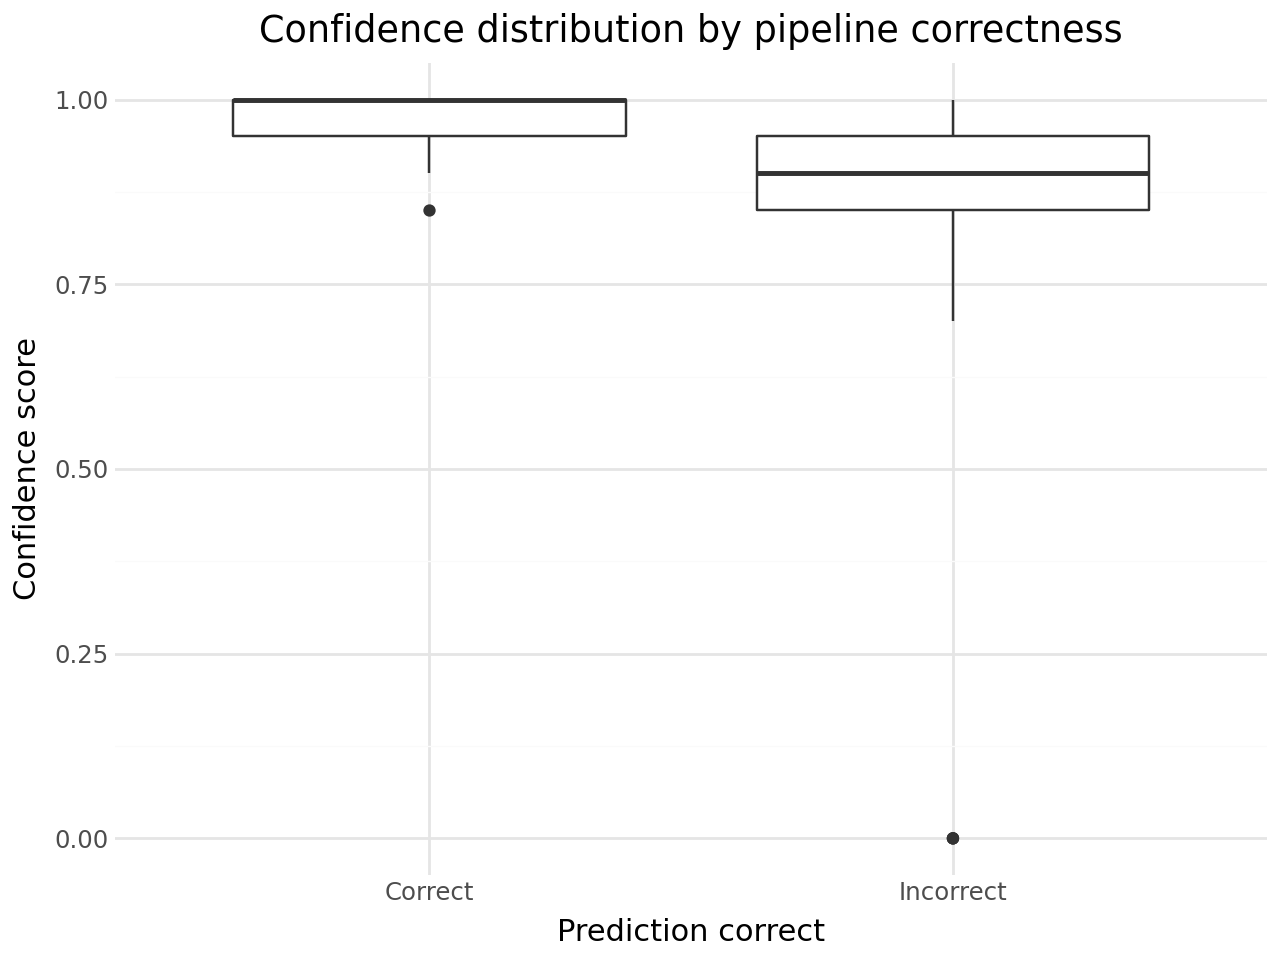

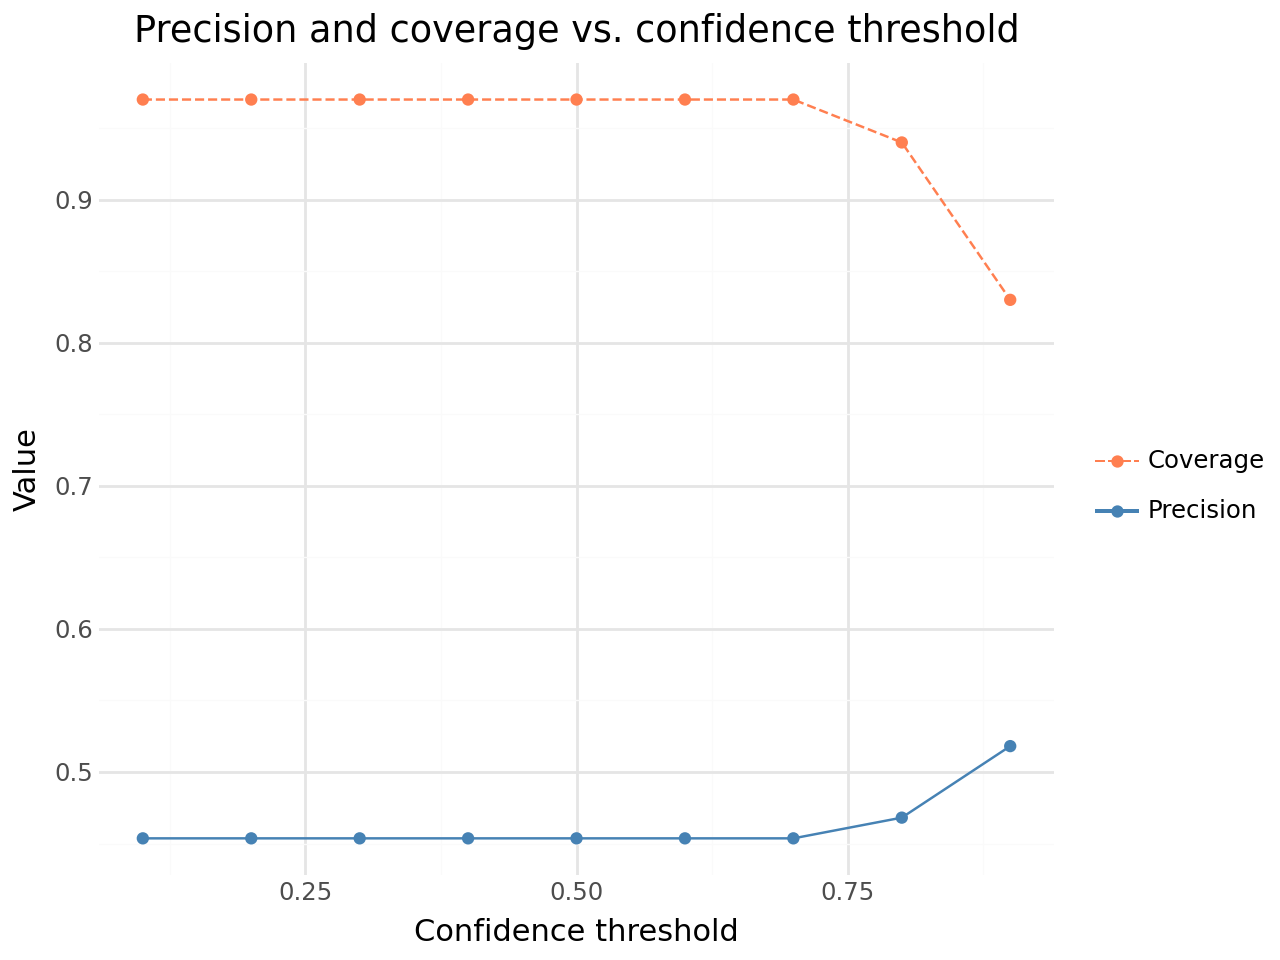

In [34]:
from plotnine import (
    ggplot, aes,
    geom_boxplot, geom_line, geom_point,
    scale_color_manual, scale_linetype_manual,
    labs, theme_minimal,
)


# --- Left: confidence distribution by correctness ---
results_plot = results.assign(
    correctness=results["pipeline_correct"].map({False: "Incorrect", True: "Correct"})
)

p1 = (
    ggplot(results_plot, aes(x="correctness", y="confidence"))
    + geom_boxplot()
    + labs(
        title="Confidence distribution by pipeline correctness",
        x="Prediction correct",
        y="Confidence score",
    )
    + theme_minimal()
)

# --- Right: precision and coverage vs confidence threshold ---
thresholds = [i / 10 for i in range(1, 10)]
rows = []
for t in thresholds:
    subset = results[results["confidence"] >= t]
    if len(subset) > 0:
        rows += [
            {"threshold": t, "metric": "Precision", "value": subset["pipeline_correct"].mean()},
            {"threshold": t, "metric": "Coverage",  "value": len(subset) / len(results)},
        ]

df_thresh = pd.DataFrame(rows)

p2 = (
    ggplot(df_thresh, aes(x="threshold", y="value", color="metric", linetype="metric"))
    + geom_line()
    + geom_point()
    + scale_color_manual(values={"Precision": "steelblue", "Coverage": "coral"})
    + scale_linetype_manual(values={"Precision": "solid", "Coverage": "dashed"})
    + labs(
        title="Precision and coverage vs. confidence threshold",
        x="Confidence threshold",
        y="Value",
        color="",
        linetype="",
    )
    + theme_minimal()
)

from IPython.display import display
display(p1)
display(p2)